# Benchmark Dataset Collection

## 1. CS - Bench

In [2]:
import json

validation_dataset = '../datasets/benchmark/CS Bench/cs-bench-valid.jsonl'
test_dataset = '../datasets/benchmark/CS Bench/cs-bench-test.jsonl'

questions = []
question_types = set()
with open(validation_dataset,"r",encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        question_types.add(record["Format"])
        questions.append(record)

with open(test_dataset,"r",encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        questions.append(record)

print(len(questions))
print(question_types)
print(questions[0])

2419
{'Assertion', 'Open-ended', 'Fill-in-the-blank', 'Multiple-choice'}
{'ID': 2184, 'Split': 'Valid', 'Domain': 'Data Structure and Algorithm', 'SubDomain': 'Overview', 'Format': 'Multiple-choice', 'Tag': 'Knowledge', 'Language': 'English', 'Question': 'Do two different data structures necessarily have different logical and physical structures?', 'A': 'Certainly different', 'B': 'May be the same, such as binary tree and binary search tree.', 'C': 'The logical structure is always the same, while the physical structure varies.', 'D': 'The logical structure is always different, while the physical structure remains the same.', 'Answer': 'B'}


In [3]:
mcqs = [q for q in questions if q["Format"] == "Multiple-choice"]
print(len(mcqs))
print(mcqs[0])

1481
{'ID': 2184, 'Split': 'Valid', 'Domain': 'Data Structure and Algorithm', 'SubDomain': 'Overview', 'Format': 'Multiple-choice', 'Tag': 'Knowledge', 'Language': 'English', 'Question': 'Do two different data structures necessarily have different logical and physical structures?', 'A': 'Certainly different', 'B': 'May be the same, such as binary tree and binary search tree.', 'C': 'The logical structure is always the same, while the physical structure varies.', 'D': 'The logical structure is always different, while the physical structure remains the same.', 'Answer': 'B'}


In [4]:
open_ended = [q for q in questions if q["Format"] == "Open-ended"]
print(len(open_ended))
print(open_ended[0])

189
{'ID': 2242, 'Split': 'Valid', 'Domain': 'Data Structure and Algorithm', 'SubDomain': 'Overview', 'Format': 'Open-ended', 'Tag': 'Reasoning', 'Language': 'English', 'Question': 'Are the logical structure and the physical structure necessarily different for two distinct data structures?', 'Answer': 'For two different data structures, it is entirely possible for their logical and physical structures to be the same. For example, binary trees and binary search trees can use the same logical representation and storage method of binary trees. The former is usually used to represent hierarchical relationships, while the latter is commonly used for sorting and searching. Although both have operations such as building a tree, inserting nodes, deleting nodes, and searching for nodes, the definitions of these operations are different for binary trees and binary search trees. Taking node search as an example, the time complexity for a binary tree is O(n), while for a binary search tree, the ti

In [5]:
assertion = [q for q in questions if q["Format"] == "Assertion"]
print(len(assertion))
print(assertion[0])

491
{'ID': 2228, 'Split': 'Valid', 'Domain': 'Data Structure and Algorithm', 'SubDomain': 'Linear List', 'Format': 'Assertion', 'Tag': 'Knowledge', 'Language': 'English', 'Question': 'The size of the storage space occupied by a sequential list is independent of the type of elements.', 'Answer': False}


In [6]:
fill_in_the_blank = [q for q in questions if q["Format"] == "Fill-in-the-blank"]
print(len(fill_in_the_blank))
print(fill_in_the_blank[0])

258
{'ID': 2240, 'Split': 'Valid', 'Domain': 'Data Structure and Algorithm', 'SubDomain': 'Tree', 'Format': 'Fill-in-the-blank', 'Tag': 'Reasoning', 'Language': 'English', 'Question': 'In a binary tree, if there are two nodes m and n, and m is an ancestor of n, then the path from m to n can be found using ().', 'Answer': 'Post-order', 'Explanation': 'During the post-order traversal return, visiting the root node allows us to output the nodes on the path from n to m in a bottom-up manner. If a non-recursive algorithm is used, when the post-order traversal reaches n, the nodes on the path from the root to n via parent pointers are all remembered in the stack, which can also be used to find the path from m to n.'}


In [7]:
benchmark_questions = []
for q in questions:
    if q["Format"] == "Multiple-choice":
        bq = {"Question": q["Question"], "Options": [{key: q[key]} for key in "ABCD"], "Answer":q["Answer"],"Format":q["Format"]}
        benchmark_questions.append(bq)
    elif q["Format"] == "Assertion":
        bq = {"Question": q["Question"], "Options": [{"A":"True","B":"False"}], "Answer":"A" if q["Answer"] else "B","Format":q["Format"]}
        benchmark_questions.append(bq)
    else:
        bq = {"Question" : q["Question"],"Options": "N/A", "Answer":q["Answer"],"Format":q["Format"]}
        benchmark_questions.append(bq)

print("Total:",len(benchmark_questions))
print("Multiple Choice:",len(mcqs))
print("Assertion:",len(assertion))
print("Fill-in-the-blank:",len(fill_in_the_blank))
print("Open-ended:",len(open_ended))

Total: 2419
Multiple Choice: 1481
Assertion: 491
Fill-in-the-blank: 258
Open-ended: 189


In [8]:
import json
file_path = "../datasets/benchmark/CS Bench/cs-bench.jsonl"
with open(file_path, "w", encoding="utf-8") as f:
    for q in benchmark_questions:
        f.write(json.dumps(q, ensure_ascii=False) + "\n")

In [12]:
questions = []
question_types = set()
domain_types = set()
subdomain_types = {}
tag_types = set()

with open(validation_dataset, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        question_types.add(record["Format"])
        domain_types.add(record["Domain"])
        tag_types.add(record["Tag"])

        if record["Domain"] not in subdomain_types:
            subdomain_types[record["Domain"]] = {record["SubDomain"]}
        else:
            subdomain_types[record["Domain"]].add(record["SubDomain"])
        questions.append(record)

with open(test_dataset, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        questions.append(record)

print(len(questions))
print(question_types)
print(domain_types)
print(subdomain_types)
print(tag_types)

2419
{'Assertion', 'Open-ended', 'Fill-in-the-blank', 'Multiple-choice'}
{'Operating System', 'Computer Network', 'Computer Organization', 'Data Structure and Algorithm'}
{'Data Structure and Algorithm': {'Overview', 'Graph', 'Stack, Queue, and Array', 'Searching', 'Linear List', 'String', 'Sorting', 'Tree'}, 'Computer Organization': {'Data Representation and Operation', 'Overview', 'Input/Output System', 'Bus', 'Instruction System', 'Storage System', 'Central Processing Unit'}, 'Computer Network': {'Physical Layer', 'Overview and Architecture', 'Transport Layer', 'Application Layer', 'Data Link Layer', 'Network Layer'}, 'Operating System': {'Processes and Threads', 'Overview', 'Input/Output Management', 'Memory Management', 'File Management'}}
{'Knowledge', 'Reasoning'}


### Dataset Statistics

- Domain & Subdomain Statistics

In [13]:
domain_count = {}
for q in questions:
    domain = q["Domain"]
    sub_domain = q["SubDomain"]
    if domain not in domain_count:
        domain_count[domain] = {sub_domain : 1}
    else:
        if sub_domain not in domain_count[domain]:
            domain_count[domain][sub_domain] = 1
        else:
            domain_count[domain][sub_domain] += 1
print(domain_count)

{'Data Structure and Algorithm': {'Overview': 42, 'Linear List': 69, 'Stack, Queue, and Array': 88, 'String': 33, 'Tree': 107, 'Graph': 92, 'Searching': 79, 'Sorting': 89}, 'Computer Organization': {'Overview': 56, 'Data Representation and Operation': 109, 'Storage System': 112, 'Instruction System': 78, 'Central Processing Unit': 122, 'Bus': 67, 'Input/Output System': 78}, 'Computer Network': {'Overview and Architecture': 74, 'Physical Layer': 82, 'Data Link Layer': 158, 'Network Layer': 150, 'Transport Layer': 91, 'Application Layer': 102}, 'Operating System': {'Overview': 83, 'Processes and Threads': 175, 'Memory Management': 108, 'Input/Output Management': 92, 'File Management': 83}}


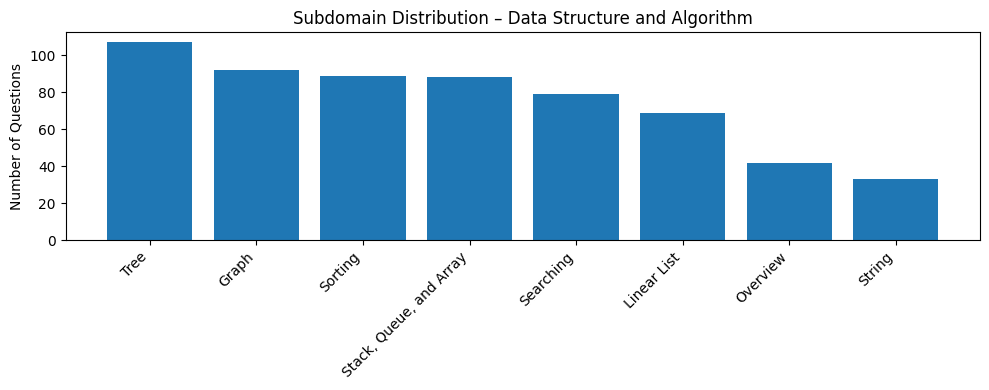

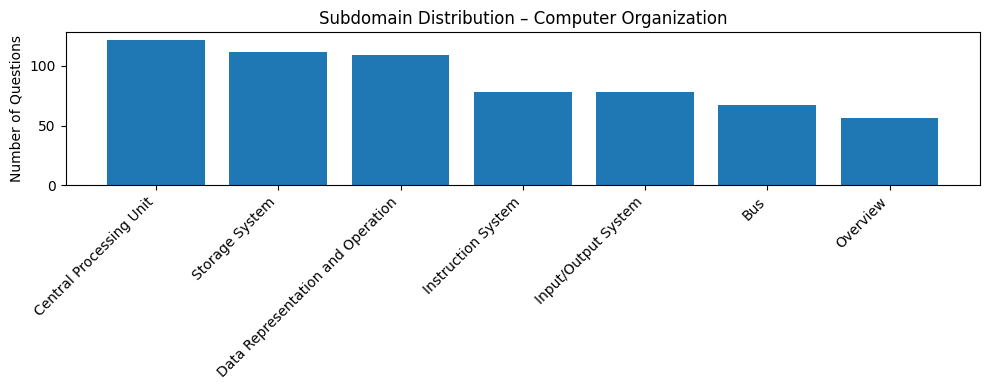

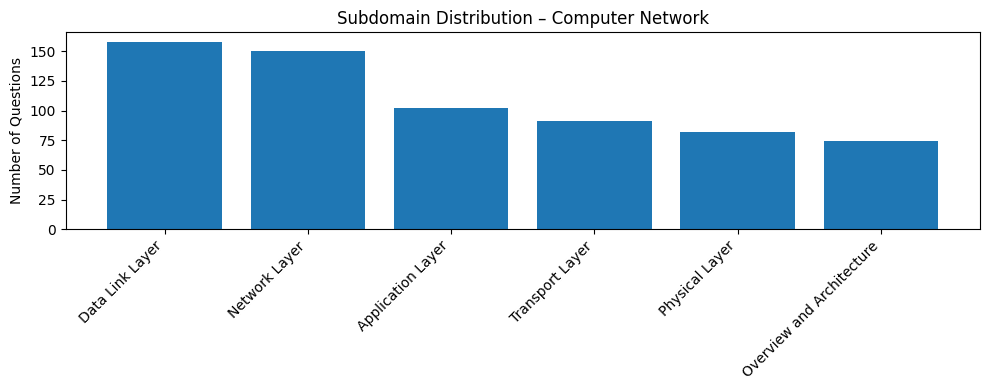

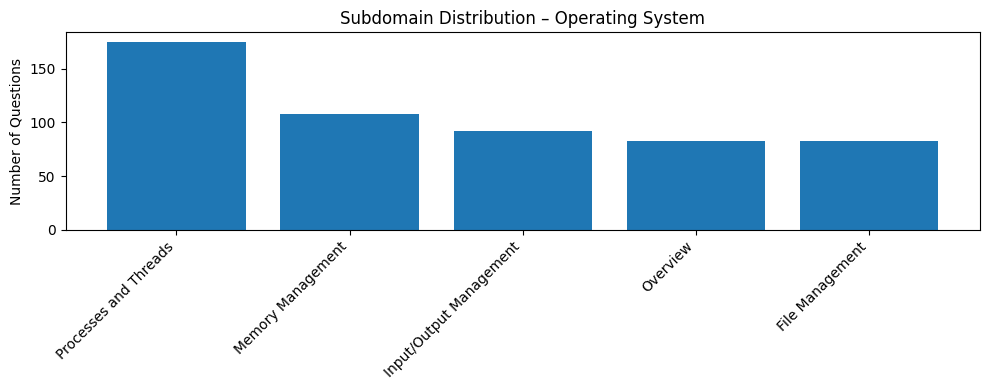

In [15]:
import matplotlib.pyplot as plt
def plot_domain_distributions_sorted(domain_count):
    for domain, subdomains in domain_count.items():
        items = sorted(subdomains.items(), key=lambda x: x[1], reverse=True)
        names = [k for k, _ in items]
        counts = [v for _, v in items]

        plt.figure(figsize=(10, 4))
        plt.bar(names, counts)
        plt.title(f"Subdomain Distribution – {domain}")
        plt.ylabel("Number of Questions")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
plot_domain_distributions_sorted(domain_count)

- Domain & Subdomain & Tag Statistics 

In [16]:
domain_distribution = {}
for q in questions:
    domain = q["Domain"]
    sub_domain = q["SubDomain"]
    tag = q["Tag"]
    if domain not in domain_distribution:
        domain_distribution[domain] = {sub_domain : { tag : 1}}
    else:
        if sub_domain not in domain_distribution[domain]:
            domain_distribution[domain][sub_domain] = {tag : 1}
        elif tag not in domain_distribution[domain][sub_domain]:
            domain_distribution[domain][sub_domain][tag] = 1
        else:
            domain_distribution[domain][sub_domain][tag] += 1
print(domain_distribution)

{'Data Structure and Algorithm': {'Overview': {'Knowledge': 36, 'Reasoning': 6}, 'Linear List': {'Knowledge': 52, 'Reasoning': 17}, 'Stack, Queue, and Array': {'Knowledge': 55, 'Reasoning': 33}, 'String': {'Knowledge': 28, 'Reasoning': 5}, 'Tree': {'Knowledge': 46, 'Reasoning': 61}, 'Graph': {'Knowledge': 59, 'Reasoning': 33}, 'Searching': {'Knowledge': 44, 'Reasoning': 35}, 'Sorting': {'Knowledge': 36, 'Reasoning': 53}}, 'Computer Organization': {'Overview': {'Knowledge': 45, 'Reasoning': 11}, 'Data Representation and Operation': {'Knowledge': 46, 'Reasoning': 63}, 'Storage System': {'Knowledge': 71, 'Reasoning': 41}, 'Instruction System': {'Knowledge': 53, 'Reasoning': 25}, 'Central Processing Unit': {'Knowledge': 93, 'Reasoning': 29}, 'Bus': {'Knowledge': 56, 'Reasoning': 11}, 'Input/Output System': {'Knowledge': 54, 'Reasoning': 24}}, 'Computer Network': {'Overview and Architecture': {'Knowledge': 63, 'Reasoning': 11}, 'Physical Layer': {'Knowledge': 55, 'Reasoning': 27}, 'Data Lin

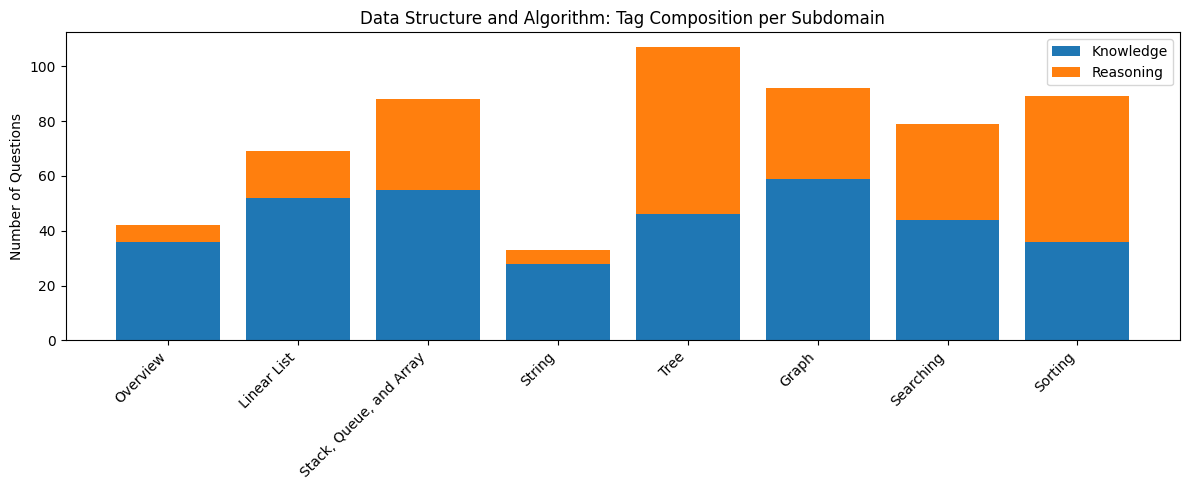

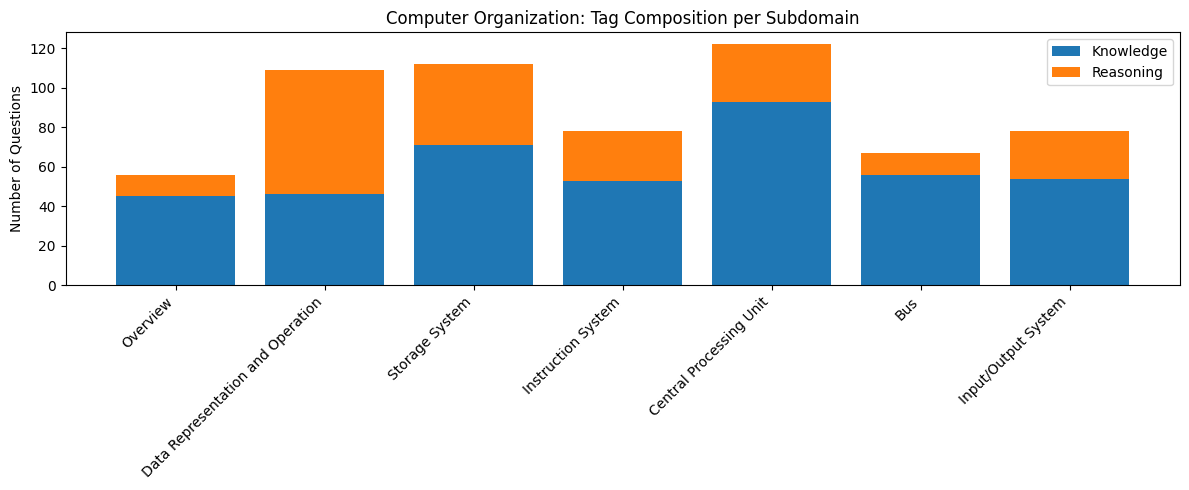

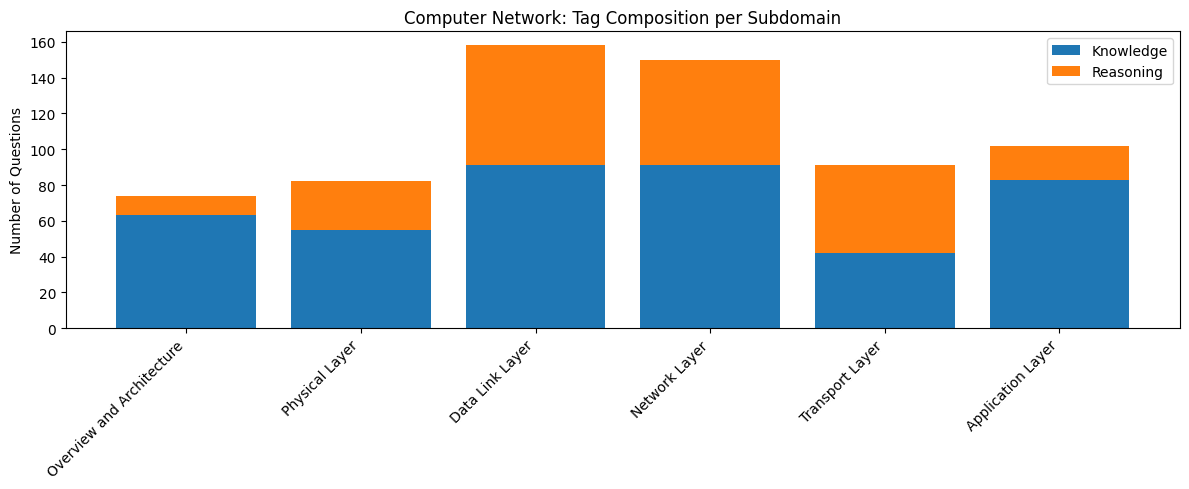

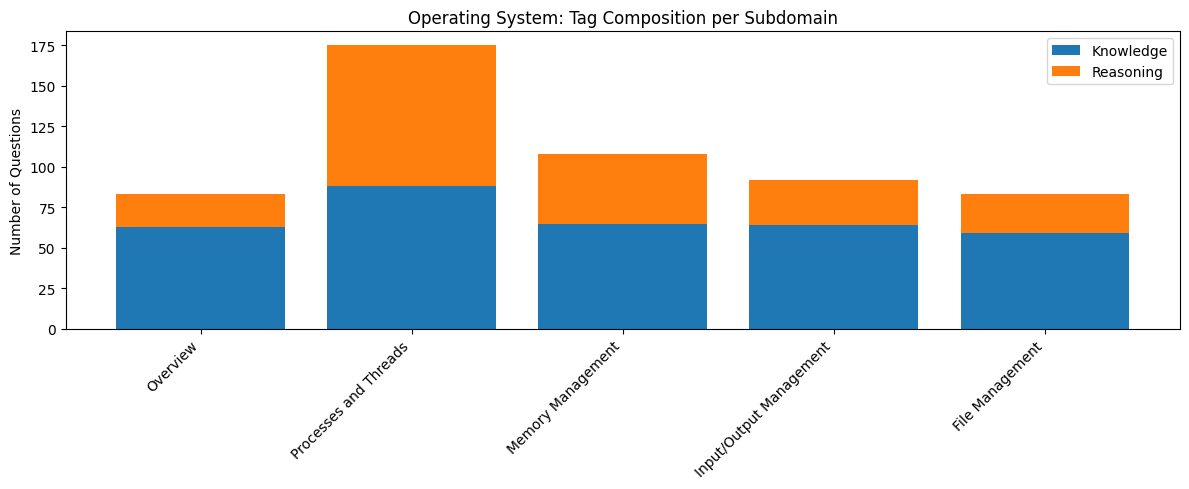

In [19]:
import numpy as np
def plot_domain_stacked(domain_distribution):
    for domain, subdomains in domain_distribution.items():
        subdomain_names = list(subdomains.keys())
        tags = set()

        for sd in subdomains.values():
            tags.update(sd.keys())
        tags = sorted(tags)

        bottom = np.zeros(len(subdomain_names))

        plt.figure(figsize=(12, 5))

        for tag in tags:
            values = [
                subdomains[sd].get(tag, 0)
                for sd in subdomain_names
            ]
            plt.bar(subdomain_names, values, bottom=bottom, label=tag)
            bottom += np.array(values)

        plt.title(f"{domain}: Tag Composition per Subdomain")
        plt.ylabel("Number of Questions")
        plt.xticks(rotation=45, ha="right")
        plt.legend()
        plt.tight_layout()
        plt.show()
plot_domain_stacked(domain_distribution)

- Multiple Choice Questions

In [41]:
mcqs = [q for q in benchmark_questions if q["Format"] == "Multiple-choice"]
total_mcqs = len(mcqs)
answer_distribution = {"A":0,"B":0,"C":0,"D":0}
for q in mcqs:
    answer_distribution[q["Answer"]] += 1
print(answer_distribution)
for key in "ABCD":
    print(f"{key} : {float(answer_distribution[key]/total_mcqs) * 100}")

{'A': 403, 'B': 384, 'C': 382, 'D': 312}
A : 27.211343686698175
B : 25.928426738690074
C : 25.79338284942606
D : 21.066846725185687


- Assertion

In [43]:
assertions = [q for q in benchmark_questions if q["Format"] == "Assertion"]
total_assertions = len(assertions)
answer_distribution = {"A":0,"B":0}
for q in assertions:
    answer_distribution[q["Answer"]] += 1
print(answer_distribution)
for key in "AB":
    print(f"{key} : {float(answer_distribution[key]/total_assertions) * 100}")

{'A': 235, 'B': 256}
A : 47.86150712830957
B : 52.138492871690424


## 2. GATE CS Questions

### 1. Convert PDFs to Markdown 

In [ ]:
import requests
from pathlib import Path
MARKER_URL = ""

def convert_pdf_to_markdown(pdf_path: str, out_md_path: str):
    pdf_path = Path(pdf_path)

    with pdf_path.open("rb") as f:
        files = {
            "file": (pdf_path.name, f, "application/pdf")
        }
        data = {
            "output_format": "markdown",
            "force_ocr": True,
            "paginate_output": False
        }

        r = requests.post(MARKER_URL, files=files, data=data)
        r.raise_for_status()
        result = r.json()

    markdown = result.get("output")
    if not markdown:
        raise RuntimeError(f"Marker returned no markdown: {result}")

    with open(out_md_path, "w", encoding="utf-8") as out:
        out.write(markdown)

#### Create a markdown folder

In [4]:
import os
base_md_folder = "../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/markdown"
os.makedirs(base_md_folder,exist_ok=True)

#### Convert question pdfs to markdown and store 

In [5]:
base_pdf_folder = "../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers"
file_paths = []
for file_path in os.listdir(base_pdf_folder):
    if file_path.endswith(".pdf"):
        file_path = os.path.join(base_pdf_folder,file_path)
        file_paths.append(file_path)
print(file_paths)

['../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2011 - CS - KEY.pdf', '../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2012 - CS - KEY.pdf', '../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2019 - CS - KEY.pdf', '../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2020- CS - KEY.pdf', '../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2021- CS1 - KEY.pdf', '../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2021- CS2 - KEY.pdf', '../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2022- CS1 - KEY.pdf', '../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2023- CS1 - KEY.pdf']


In [12]:
error_files = []
for file_path in file_paths:
    md_file_path = os.path.join(base_md_folder,os.path.basename(file_path)[:-4]) + ".md"
    try:
        convert_pdf_to_markdown(file_path,md_file_path)
        print("Converted File:",file_path)
    except Exception as e:
        error_files.append(file_path)

Converted File: ../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2011 - CS - KEY.pdf
Converted File: ../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2012 - CS - KEY.pdf
Converted File: ../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2019 - CS - KEY.pdf
Converted File: ../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2020- CS - KEY.pdf
Converted File: ../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2021- CS1 - KEY.pdf
Converted File: ../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2021- CS2 - KEY.pdf
Converted File: ../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2022- CS1 - KEY.pdf
Converted File: ../datasets/benchmark/GATE/Gate-CS-2011-2024/Solved Papers/2023- CS1 - KEY.pdf


In [13]:
print(error_files)

[]


### 2. Extract MCQ's from Markdown

In [ ]:
base_question_md_folder = "../datasets/benchmark/GATE/Gate-CS-2011-2024/CS/markdown"
base_ans_md_folder = "../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown"

import os 
for file_path in os.listdir(base_question_md_folder):
    print(os.path.join(base_question_md_folder,file_path))

#### Experiment with Regex


In [ ]:
`file_path = "../datasets/benchmark/GATE/Gate-CS-2011-2024/CS/markdown/2011 - CS.md"
file_text = ""
with open(file_path,"r",encoding="utf-8") as f:
    file_text = f.read()
    print(file_text)

import re
question_pattern = r"""
^\s*-?\s*Q\.(\d+)        # question start
\s*
(.*?)                   # question body
(?=                     # stop when we see:
   ^\s*-?\s*Q\.\d+      # next question
 | ^\s*\#+\s*Q\.         # section header
 | \Z                   # end of text
)
"""
matches = re.findall(question_pattern, file_text, flags=re.DOTALL | re.MULTILINE | re.VERBOSE)
print(len(matches))
md_questions = []
for qno,content in matches:
    print(f"Question {qno}:");
    print(content.strip())
    md_questions.append(content.strip())
    print("-"*40)

In [67]:
# Remove questions with images 
md_questions = [q for q in md_questions if ".jpeg" not in q]
print(len(md_questions))

43


In [69]:
option_re = re.compile(
    r"^\s*-?\s*\(([A-D])\)\s*(.*?)(?=^\s*-?\s*\([A-D]\)|\Z)",
    re.DOTALL | re.MULTILINE
)

option_re = re.compile(
    r"""
    ^\s*-?\s*            # optional bullet / whitespace
    \(([A-D])\)          # option label
    \s*
    (.*?)                # option text (non-greedy)
    (?=                  # STOP when we see:
        ^\s*-?\s*\([A-D]\)   # next option
      | ^\s*\#{2,}           # markdown header (##, ###, ####)
      | \Z                   # end of string
    )
    """,
    re.DOTALL | re.MULTILINE | re.VERBOSE
)

parsed_questions = []

for q in md_questions:
    q = q.strip()

    q_match = question_re.search(q)
    if not q_match:
        continue 

    question_text = q_match.group(1).strip()

    options = {}
    for label, text in option_re.findall(q):
        options[label] = text.strip()

    parsed_questions.append({
        "question": question_text,
        "options": options
    })
parsed_questions

[{'question': 'In a compiler, keywords of a language are recognized during',
  'options': {'A': 'parsing of the program',
   'B': 'the code generation',
   'C': 'the lexical analysis of the program',
   'D': 'dataflow analysis'}},
 {'question': 'A layer-4 firewall (a device that can look at all protocol headers up to the transport layer) CANNOT',
  'options': {'A': 'block entire HTTP traffic during 9:00PM and 5:00AM',
   'B': 'block all ICMP traffic',
   'C': 'stop incoming traffic from a specific IP address but allow outgoing traffic to the same IP address',
   'D': 'block TCP traffic from a specific user on a multi-user system during 9:00PM and 5:00AM'}},
 {'question': 'If two fair coins are flipped and at least one of the outcomes is known to be a head, what is the probability that both outcomes are heads?',
  'options': {'A': '1/3', 'B': '1/4', 'C': '1/2', 'D': '2/3'}},
 {'question': 'Consider different activities related to email.\n  - m1: Send an email from a mail client to a mai

In [70]:
len(parsed_questions)

43

In [72]:
dependent_ques_re = re.compile(
    r"""
    (?i)                                  # case-insensitive
    (
        # ---- figure / diagram / graph dependencies ----
        refer\ to\ the\ (figure|diagram|graph)
      | following\ (figure|diagram|graph)
      | above\ (figure|diagram|graph)
      | below\ (figure|diagram|graph)
      | shown\ (above|below)

        # ---- common data blocks ----
      | common\ data
      | common\ information
    )
    """,
    re.VERBOSE
)

filtered_questions = [q for q in parsed_questions if not dependent_ques_re.search(q["question"])]
print(len(filtered_questions))

43


#### MCQs extraction regex pipeline

In [103]:
import re

def is_question_dependent(question_text):
    image_re =  re.compile(
        r"!\[[^\]]*\]\([^)]+\)",   # markdown image syntax
        re.MULTILINE
    )
    if image_re.search(question_text):
        return True
    dependent_ques_re = re.compile(
    r"""
    (?i)                                  # case-insensitive
    (
        # ---- figure / diagram / graph dependencies ----
        refer\ to\ the\ (figure|diagram|graph)
      | following\ (figure|diagram|graph)
      | above\ (figure|diagram|graph)
      | below\ (figure|diagram|graph)
      | shown\ (above|below)

        # ---- common data blocks ----
      | common\ data
      | common\ information
    )
    """,
    re.VERBOSE
    )
    return dependent_ques_re.search(question_text) is not None

def extract_mcq_from_question_blocks(question_block):
    option_re = re.compile(
    r"^\s*-?\s*\(([A-D])\)\s*(.*?)(?=^\s*-?\s*\([A-D]\)|\Z)",
    re.DOTALL | re.MULTILINE
    )
    option_re = re.compile(
        r"""
        ^\s*-?\s*            # optional bullet / whitespace
        \(([A-D])\)          # option label
        \s*
        (.*?)                # option text (non-greedy)
        (?=                  # STOP when we see:
            ^\s*-?\s*\([A-D]\)   # next option
          | ^\s*\#{2,}           # markdown header (##, ###, ####)
          | \Z                   # end of string
        )
        """,
        re.DOTALL | re.MULTILINE | re.VERBOSE
    )
    
    question_block = question_block.strip()
    if is_question_dependent(question_block):
        return None
    
    q_match = question_re.search(question_block)
    if not q_match:
        return None

    question_text = q_match.group(1).strip()
    
    options = {}
    for label, text in option_re.findall(question_block):
        options[label] = text.strip()

    return {
        "question": question_text,
        "options": options
    }

def extract_question_blocks(text):
    question_pattern = r"""
    ^\s*-?\s*Q\.(\d+)        # question start
    \s*
    (.*?)                   # question body
    (?=                     # stop when we see:
       ^\s*-?\s*Q\.\d+      # next question
     | ^\s*\#+\s*Q\.         # section header
     | \Z                   # end of text
    )
    """
    matches = re.findall(question_pattern, file_text, flags=re.DOTALL | re.MULTILINE | re.VERBOSE)
    questions = []
    for qno,content in matches:
        questions.append({"qno":qno,"question":content.strip()})
    return questions



def extract_mcqs_from_markdown(file_name,md_text):
    question_blocks = extract_question_blocks(md_text)
    parsed_questions = []
    for question in question_blocks:
        parsed_question = extract_mcq_from_question_blocks(question["question"])
        if parsed_question:
            parsed_questions.append({"qno":question["qno"],"question":parsed_question["question"],"options":parsed_question["options"],"file":file_name[:-3]})
    return parsed_questions

In [104]:
import os
base_question_md_folder = "../datasets/benchmark/GATE/Gate-CS-2011-2024/CS/markdown"
base_ans_md_folder = "../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown"
all_questions = []
for file_name in os.listdir(base_question_md_folder):
    file_path = os.path.join(base_question_md_folder,file_name)
    if file_path.endswith(".md"):
        with open(file_path,"r",encoding="utf-8") as f:
            file_questions = extract_mcqs_from_markdown(file_name,f.read())
            print(f"{file_name} : {len(file_questions)}")
            all_questions += file_questions

2011 - CS.md : 42
2012 - CS.md : 42
2013 - CS.md : 42
2014 - CS1.md : 42
2014 - CS2.md : 42
2014 - CS3.md : 42
2015 - CS1.md : 42
2015 - CS2.md : 42
2015 - CS3.md : 42
2016 - CS1.md : 42
2016 - CS2.md : 42
2017 - CS1.md : 42
2017 - CS2.md : 42
2018 - CS.md : 42
2019 - CS.md : 42
2020 - CS.md : 42
2021 - CS1.md : 42
2021 - CS2.md : 42
2022 - CS.md : 42
2023 - CS.md : 42
2024 - CS1.md : 42
2024 - CS2.md : 42
2025 - CS1.md : 42
2025 - CS2.md : 42


In [105]:
print(len(all_questions))
all_questions

1008


[{'qno': '1',
  'question': 'In a compiler, keywords of a language are recognized during',
  'options': {'A': 'parsing of the program',
   'B': 'the code generation',
   'C': 'the lexical analysis of the program',
   'D': 'dataflow analysis'},
  'file': '2011 - CS'},
 {'qno': '2',
  'question': 'A layer-4 firewall (a device that can look at all protocol headers up to the transport layer) CANNOT',
  'options': {'A': 'block entire HTTP traffic during 9:00PM and 5:00AM',
   'B': 'block all ICMP traffic',
   'C': 'stop incoming traffic from a specific IP address but allow outgoing traffic to the same IP address',
   'D': 'block TCP traffic from a specific user on a multi-user system during 9:00PM and 5:00AM'},
  'file': '2011 - CS'},
 {'qno': '3',
  'question': 'If two fair coins are flipped and at least one of the outcomes is known to be a head, what is the probability that both outcomes are heads?',
  'options': {'A': '1/3', 'B': '1/4', 'C': '1/2', 'D': '2/3'},
  'file': '2011 - CS'},
 {

### 3. Extracting answer keys from markdown

In [110]:
base_question_md_folder = "../datasets/benchmark/GATE/Gate-CS-2011-2024/CS/markdown"
base_ans_md_folder = "../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown"

In [113]:
import os 
for file_path in os.listdir(base_ans_md_folder):
    print(os.path.join(base_ans_md_folder,file_path))

../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/.ipynb_checkpoints
../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/2011 - CS - KEY.md
../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/2012 - CS - KEY.md
../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/2013 - CS - KEY.md
../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/2014 - CS1 - KEY.md
../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/2014 - CS2 - KEY.md
../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/2014 - CS3 - KEY.md
../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/2015 - CS1 - KEY.md
../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/2015 - CS2 - KEY.md
../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/2015 - CS3 - KEY.md
../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/2016 - CS1 - KEY.md
../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/2016 - CS2 - KEY.md
../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdo

In [1]:
file_path = "../datasets/benchmark/GATE/Gate-CS-2011-2024/Keys/markdown/2011 - CS - KEY.md"
ans_key_md_text = ""
with open(file_path,"r",encoding="utf-8") as f:
    ans_key_md_text = f.read()
    print(ans_key_md_text)

GATE 2011 - Answer Key - Paper : CS

| Paper | Question no. | Code : A | Code : B | Code : C | Code : D |
|-------|--------------|----------|----------|----------|----------|
| CS    | 1            | С        | В        | Α        | С        |
| CS    | 2            | D        | D        | D        | Α        |
| CS    | 3            | Α        | А        | D        | В        |
| CS    | 4            | С        | С        | D        | С        |
| CS    | 5            | В        | В        | В        | D        |
| CS    | 6            | С        | С        | А        | В        |
| CS    | 7            | Α        | А        | С        | А        |
| CS    | 8            | В        | В        | В        | С        |
| CS    | 9            | D        | D        | С        | В        |
| CS    | 10           | D        | С        | А        | С        |
| CS    | 11           | D        | В        | D        | Α        |
| CS    | 12           | Α        | А        | С        | В       

In [2]:
import re

row_re = re.compile(
    r"""
    ^\|\s*CS\s*\|          # CS paper
    \s*(\d+)\s*\|          # Question number
    \s*([A-DΑΒСＤ])\s*\|   # Code A answer (Latin + Greek)
    """,
    re.MULTILINE | re.VERBOSE
)

def normalize_option(opt):
    greek_to_latin = {
        "Α": "A",
        "Β": "B",
        "С": "C",   # Cyrillic/Greek-looking C
        "Ｄ": "D"
    }
    return greek_to_latin.get(opt, opt)

def extract_code_a_answers(md_text):
    answers = {}
    for qno, ans in row_re.findall(md_text):
        answers[int(qno)] = normalize_option(ans)
    return answers
extract_code_a_answers(ans_key_md_text)

{1: 'C',
 2: 'D',
 3: 'A',
 4: 'C',
 6: 'C',
 7: 'A',
 9: 'D',
 10: 'D',
 11: 'D',
 12: 'A',
 13: 'D',
 15: 'A',
 16: 'C',
 18: 'C',
 19: 'A',
 21: 'D',
 22: 'C',
 24: 'C',
 25: 'A',
 26: 'C',
 28: 'A',
 31: 'D',
 32: 'A',
 33: 'D',
 34: 'A',
 35: 'A',
 36: 'D',
 38: 'C',
 39: 'C',
 43: 'D',
 45: 'A',
 46: 'C',
 47: 'C',
 49: 'D',
 50: 'D',
 52: 'A',
 53: 'C',
 55: 'C',
 56: 'A',
 58: 'C',
 60: 'D',
 61: 'C',
 62: 'D',
 63: 'A',
 64: 'C',
 65: 'D'}

### 4. Combining questions and answer